In [3]:
import pandas as pd
import numpy as np
import os

In [4]:
demo = pd.read_csv(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\data\raw\ASCII\DEMO23Q1.txt", 
                   delimiter='$', 
                   encoding='latin-1',
                   low_memory=False)

drug = pd.read_csv(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\data\raw\ASCII\DRUG23Q1.txt", 
                   delimiter='$', 
                   encoding='latin-1',
                   low_memory=False)

reac = pd.read_csv(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\data\raw\ASCII\REAC23Q1.txt", 
                   delimiter='$', 
                   encoding='latin-1',
                   low_memory=False)

outc = pd.read_csv(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\data\raw\ASCII\OUTC23Q1.txt", 
                   delimiter='$', 
                   encoding='latin-1',
                   low_memory=False)
print("DEMO:", demo.shape)
print("DRUG:", drug.shape)
print("REAC:", reac.shape)
print("OUTC:", outc.shape)

DEMO: (432144, 25)
DRUG: (1899503, 20)
REAC: (1491473, 4)
OUTC: (309217, 3)


In [5]:
print("DEMO columns:\n", demo.columns.tolist())
print("\nDRUG columns:\n", drug.columns.tolist())
print("\nREAC columns:\n", reac.columns.tolist())
print("\nOUTC columns:\n", outc.columns.tolist())

DEMO columns:
 ['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num', 'mfr_num', 'mfr_sndr', 'lit_ref', 'age', 'age_cod', 'age_grp', 'sex', 'e_sub', 'wt', 'wt_cod', 'rept_dt', 'to_mfr', 'occp_cod', 'reporter_country', 'occr_country']

DRUG columns:
 ['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr', 'cum_dose_unit', 'dechal', 'rechal', 'lot_num', 'exp_dt', 'nda_num', 'dose_amt', 'dose_unit', 'dose_form', 'dose_freq']

REAC columns:
 ['primaryid', 'caseid', 'pt', 'drug_rec_act']

OUTC columns:
 ['primaryid', 'caseid', 'outc_cod']


In [6]:
print("DEMO head:")
print(demo.head(3))

print("\nDRUG head:")
print(drug.head(3))

print("\nREAC head:")
print(reac.head(3))

print("\nOUTC head:")
print(outc.head(3))

DEMO head:
    primaryid    caseid  caseversion i_f_code    event_dt      mfr_dt  \
0  1001678118  10016781           18        F  20120330.0  20230323.0   
1   100264472  10026447            2        F         NaN  20230222.0   
2   100270603  10027060            3        F  20130201.0  20230118.0   

   init_fda_dt    fda_dt rept_cod auth_num  ... age_grp sex e_sub     wt  \
0     20140318  20230331      EXP      NaN  ...     NaN   F     Y    NaN   
1     20140321  20230228      EXP      NaN  ...     NaN   F     Y    NaN   
2     20140321  20230123      EXP      NaN  ...     NaN   F     Y  47.67   

  wt_cod   rept_dt to_mfr occp_cod  reporter_country occr_country  
0    NaN  20230331    NaN       HP                CA           CA  
1    NaN  20230228    NaN       HP                NL           NL  
2     KG  20230123    NaN       LW                US          NaN  

[3 rows x 25 columns]

DRUG head:
    primaryid    caseid  drug_seq role_cod     drugname             prod_ai  \
0  10

In [7]:
print("DEMO nulls:")
print(demo[['primaryid','age','age_grp','sex',
            'reporter_country','occp_cod']].isnull().sum())

print("\nDRUG nulls:")
print(drug[['primaryid','drugname',
            'role_cod','route']].isnull().sum())

print("\nREAC nulls:")
print(reac[['primaryid','pt']].isnull().sum())

print("\nOUTC nulls:")
print(outc[['primaryid','outc_cod']].isnull().sum())

DEMO nulls:
primaryid                0
age                 191100
age_grp             326853
sex                  63571
reporter_country         3
occp_cod              7203
dtype: int64

DRUG nulls:
primaryid         0
drugname          1
role_cod          0
route        574478
dtype: int64

REAC nulls:
primaryid    0
pt           0
dtype: int64

OUTC nulls:
primaryid    0
outc_cod     0
dtype: int64


In [8]:
# --- DEMO CLEANING ---

demo_clean = demo[['primaryid', 'age', 'sex', 'reporter_country', 'occp_cod']].copy()
demo_clean = demo_clean.dropna(subset=['age', 'sex'])

demo_clean = demo_clean[demo_clean['sex'].isin(['M', 'F'])]
demo_clean['age'] = pd.to_numeric(demo_clean['age'], errors='coerce')
demo_clean = demo_clean[(demo_clean['age'] >= 0) & (demo_clean['age'] <= 110)]

bins = [0, 17, 34, 49, 64, 110]
labels = ['0-17', '18-34', '35-49', '50-64', '65+']
demo_clean['age_group'] = pd.cut(demo_clean['age'], bins=bins, labels=labels)

demo_clean['reporter_country'] = demo_clean['reporter_country'].fillna('Unknown')
demo_clean['occp_cod'] = demo_clean['occp_cod'].fillna('Unknown')

print("DEMO cleaned:", demo_clean.shape)
print(demo_clean['age_group'].value_counts())
print(demo_clean['sex'].value_counts())

DEMO cleaned: (234598, 6)
age_group
65+      89286
50-64    63351
35-49    37427
18-34    27561
0-17     16534
Name: count, dtype: int64
sex
F    138973
M     95625
Name: count, dtype: int64


In [9]:
demo_clean.isnull().sum()

primaryid             0
age                   0
sex                   0
reporter_country      0
occp_cod              0
age_group           439
dtype: int64

In [10]:
# Fix 439 remaining age_group nulls
demo_clean = demo_clean.dropna(subset=['age_group'])
print("DEMO final shape:", demo_clean.shape)
print("DEMO nulls remaining:", demo_clean.isnull().sum().sum())

DEMO final shape: (234159, 6)
DEMO nulls remaining: 0


In [11]:
# --- DRUG CLEANING ---

drug_clean = drug[['primaryid', 'drugname', 'role_cod', 'route']].copy()
drug_clean = drug_clean[drug_clean['role_cod'] == 'PS']  #primary suspect

drug_clean = drug_clean.dropna(subset=['drugname'])
drug_clean['drugname'] = drug_clean['drugname'].str.strip().str.upper()

drug_clean['route'] = drug_clean['route'].fillna('Unknown')
drug_clean['route'] = drug_clean['route'].str.strip().str.title()

print("\nDRUG cleaned:", drug_clean.shape)
print(drug_clean['route'].value_counts().head(10))


DRUG cleaned: (432073, 4)
route
Unknown                                  164013
Oral                                     109089
Subcutaneous                              85737
Intravenous (Not Otherwise Specified)     30875
Intravenous Drip                           9894
Other                                      8808
Intra-Uterine                              4905
Intramuscular                              3948
Respiratory (Inhalation)                   3089
Topical                                    2841
Name: count, dtype: int64


In [12]:
# --- REAC CLEANING ---
reac_clean = reac[['primaryid', 'pt']].copy()

reac_clean['pt'] = reac_clean['pt'].str.strip().str.title()
reac_clean.rename(columns={'pt': 'reaction'}, inplace=True)

print("\nREAC cleaned:", reac_clean.shape)
print(reac_clean['reaction'].value_counts().head(10))
reac_clean.isnull().sum()


REAC cleaned: (1491473, 2)
reaction
Off Label Use                  37549
Drug Ineffective               30629
Fatigue                        21806
Covid-19                       18106
Death                          17386
Nausea                         17157
Diarrhoea                      16740
Pain                           16007
Product Dose Omission Issue    15681
Headache                       14892
Name: count, dtype: int64


primaryid    0
reaction     0
dtype: int64

In [13]:
# --- OUTC CLEANING ---
outc_clean = outc[['primaryid', 'outc_cod']].copy()

outcome_map = {
    'DE': 'Death',
    'LT': 'Life Threatening',
    'HO': 'Hospitalisation',
    'RI': 'Required Intervention',
    'DS': 'Disability',
    'CA': 'Congenital Anomaly',
    'OT': 'Other'
}
outc_clean['outcome_label'] = outc_clean['outc_cod'].map(outcome_map)

# Create fatal flag
outc_clean['is_fatal'] = outc_clean['outc_cod'].apply(lambda x: 1 if x == 'DE' else 0)

print("\nOUTC cleaned:", outc_clean.shape)
print(outc_clean['outcome_label'].value_counts())
outc_clean.isnull().sum()


OUTC cleaned: (309217, 4)
outcome_label
Other                    167440
Hospitalisation           85241
Death                     37704
Life Threatening          11529
Disability                 5481
Required Intervention       928
Congenital Anomaly          894
Name: count, dtype: int64


primaryid        0
outc_cod         0
outcome_label    0
is_fatal         0
dtype: int64

In [15]:
# Fix 439 remaining age_group nulls
demo_clean = demo_clean.dropna(subset=['age_group'])
print("DEMO final shape:", demo_clean.shape)
print("DEMO nulls remaining:", demo_clean.isnull().sum().sum())

DEMO final shape: (234159, 6)
DEMO nulls remaining: 0


In [16]:
# Check DRUG clean
print("\nDRUG cleaned:", drug_clean.shape)
print("DRUG nulls:\n", drug_clean.isnull().sum())
print("\nTop 10 drugs:")
print(drug_clean['drugname'].value_counts().head(10))


DRUG cleaned: (432073, 4)
DRUG nulls:
 primaryid    0
drugname     0
role_cod     0
route        0
dtype: int64

Top 10 drugs:
drugname
HUMIRA      18161
DUPIXENT    16902
SKYRIZI      7132
COSENTYX     6382
RINVOQ       5907
REVLIMID     5564
REPATHA      5505
PAXLOVID     5278
ENTRESTO     4828
MOUNJARO     4765
Name: count, dtype: int64


In [17]:
# Check REAC clean
print("\nREAC cleaned:", reac_clean.shape)
print("REAC nulls:\n", reac_clean.isnull().sum())
print("\nTop 10 reactions:")
print(reac_clean['reaction'].value_counts().head(10))


REAC cleaned: (1491473, 2)
REAC nulls:
 primaryid    0
reaction     0
dtype: int64

Top 10 reactions:
reaction
Off Label Use                  37549
Drug Ineffective               30629
Fatigue                        21806
Covid-19                       18106
Death                          17386
Nausea                         17157
Diarrhoea                      16740
Pain                           16007
Product Dose Omission Issue    15681
Headache                       14892
Name: count, dtype: int64


In [18]:
# Check OUTC clean
print("\nOUTC cleaned:", outc_clean.shape)
print("OUTC nulls:\n", outc_clean.isnull().sum())
print("\nOutcome distribution:")
print(outc_clean['outcome_label'].value_counts())
print("\nFatal cases:", outc_clean['is_fatal'].sum())
print("Fatality rate:", round(outc_clean['is_fatal'].mean() * 100, 2), "%")


OUTC cleaned: (309217, 4)
OUTC nulls:
 primaryid        0
outc_cod         0
outcome_label    0
is_fatal         0
dtype: int64

Outcome distribution:
outcome_label
Other                    167440
Hospitalisation           85241
Death                     37704
Life Threatening          11529
Disability                 5481
Required Intervention       928
Congenital Anomaly          894
Name: count, dtype: int64

Fatal cases: 37704
Fatality rate: 12.19 %


In [19]:
# PHASE 3: MERGING
# Step 1 — Merge DEMO + DRUG on primaryid
merged = demo_clean.merge(drug_clean, on='primaryid', how='inner')
print("After DEMO + DRUG merge:", merged.shape)

# Step 2 — Merge with REAC
merged = merged.merge(reac_clean, on='primaryid', how='inner')
print("After + REAC merge:", merged.shape)

# Step 3 — Merge with OUTC
merged = merged.merge(outc_clean, on='primaryid', how='inner')
print("After + OUTC merge:", merged.shape)

# Step 4 — Check final columns
print("\nFinal columns:", merged.columns.tolist())

# Step 5 — Check nulls in final merged file
print("\nFinal nulls:\n", merged.isnull().sum())

# Step 6 — Preview
print("\nSample rows:")
print(merged.head(3))


After DEMO + DRUG merge: (234022, 9)
After + REAC merge: (909009, 10)
After + OUTC merge: (1052002, 13)

Final columns: ['primaryid', 'age', 'sex', 'reporter_country', 'occp_cod', 'age_group', 'drugname', 'role_cod', 'route', 'reaction', 'outc_cod', 'outcome_label', 'is_fatal']

Final nulls:
 primaryid           0
age                 0
sex                 0
reporter_country    0
occp_cod            0
age_group           0
drugname            0
role_cod            0
route               0
reaction            0
outc_cod            0
outcome_label       0
is_fatal            0
dtype: int64

Sample rows:
    primaryid   age sex reporter_country occp_cod age_group     drugname  \
0  1001678118  56.0   F               CA       HP     50-64  SANDOSTATIN   
1  1001678118  56.0   F               CA       HP     50-64  SANDOSTATIN   
2  1001678118  56.0   F               CA       HP     50-64  SANDOSTATIN   

  role_cod         route                  reaction outc_cod outcome_label  \
0       PS 

In [21]:
# PHASE 4: EXPORT
output_path = r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\data\cleaned\faers_cleaned_2023q1.csv"

merged.to_csv(output_path, index=False)

print("File exported successfully.")
print("Shape:", merged.shape)
print("Location:", output_path)

File exported successfully.
Shape: (1052002, 13)
Location: C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\data\cleaned\faers_cleaned_2023q1.csv


In [23]:
# PHASE 5: EXPLORATORY DATA ANALYSIS

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Set plot style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

# --- 1. Overall fatality rate ---
fatal_rate = merged['is_fatal'].mean() * 100
print(f"Overall Fatality Rate: {fatal_rate:.2f}%")

# --- 2. Outcome distribution ---
print("\nOutcome Distribution:")
print(merged['outcome_label'].value_counts())

# --- 3. Top 15 drugs by report count ---
print("\nTop 15 Drugs by Report Count:")
print(merged['drugname'].value_counts().head(15))

# --- 4. Top 15 reactions ---
print("\nTop 15 Reactions:")
print(merged['reaction'].value_counts().head(15))

# --- 5. Fatality rate by age group ---
print("\nFatality Rate by Age Group:")
age_fatal = merged.groupby('age_group', observed=True)['is_fatal'].mean() * 100
print(age_fatal.round(2))

# --- 6. Fatality rate by sex ---
print("\nFatality Rate by Sex:")
sex_fatal = merged.groupby('sex')['is_fatal'].mean() * 100
print(sex_fatal.round(2))

# --- 7. Top 10 drugs by fatality rate (min 1000 reports) ---
print("\nTop 10 Drugs by Fatality Rate (min 1000 reports):")
drug_fatal = merged.groupby('drugname').agg(
    total_reports=('is_fatal', 'count'),
    fatal_cases=('is_fatal', 'sum')
).reset_index()
drug_fatal['fatality_rate'] = (drug_fatal['fatal_cases'] / 
                                drug_fatal['total_reports'] * 100).round(2)
drug_fatal = drug_fatal[drug_fatal['total_reports'] >= 1000]
print(drug_fatal.sort_values('fatality_rate', ascending=False).head(10))

Overall Fatality Rate: 7.11%

Outcome Distribution:
outcome_label
Other                    559324
Hospitalisation          312480
Death                     74839
Life Threatening          56744
Disability                41559
Required Intervention      4032
Congenital Anomaly         3024
Name: count, dtype: int64

Top 15 Drugs by Report Count:
drugname
INFLIXIMAB                28678
VEDOLIZUMAB               24054
METHOTREXATE              22536
COSENTYX                  19937
HUMIRA                    15779
HUMAN IMMUNOGLOBULIN G    14683
REMICADE                  12645
ACTEMRA                   12079
OCREVUS                   11289
CIPROFLOXACIN             10554
SANDOSTATIN LAR DEPOT     10100
XELJANZ XR                 9859
XOLAIR                     8702
XELJANZ                    8679
RITUXIMAB                  8620
Name: count, dtype: int64

Top 15 Reactions:
reaction
Off Label Use           20649
Death                   14560
Drug Ineffective        13189
Fatigue             

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\1820208372.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.values, y=outcome_counts.index, palette='Reds_r')


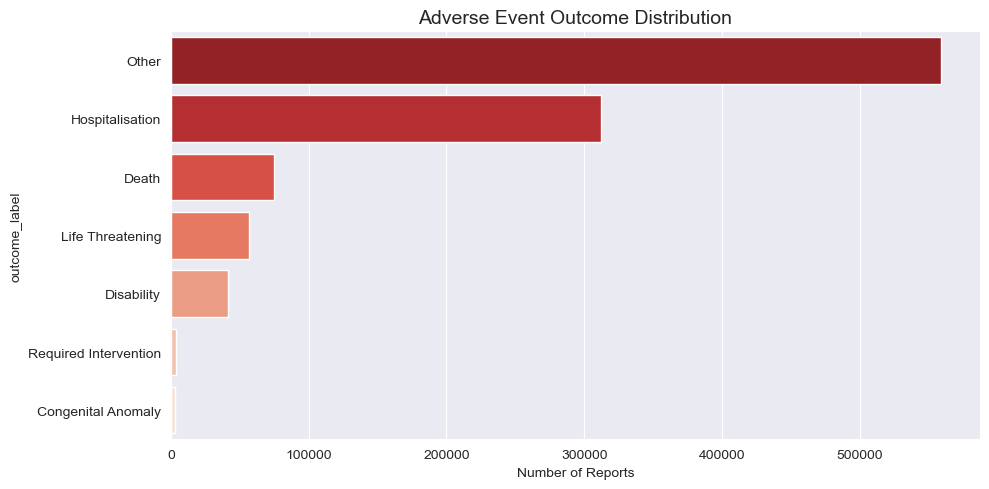

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\1820208372.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_drugs.values, y=top_drugs.index, palette='Blues_r')


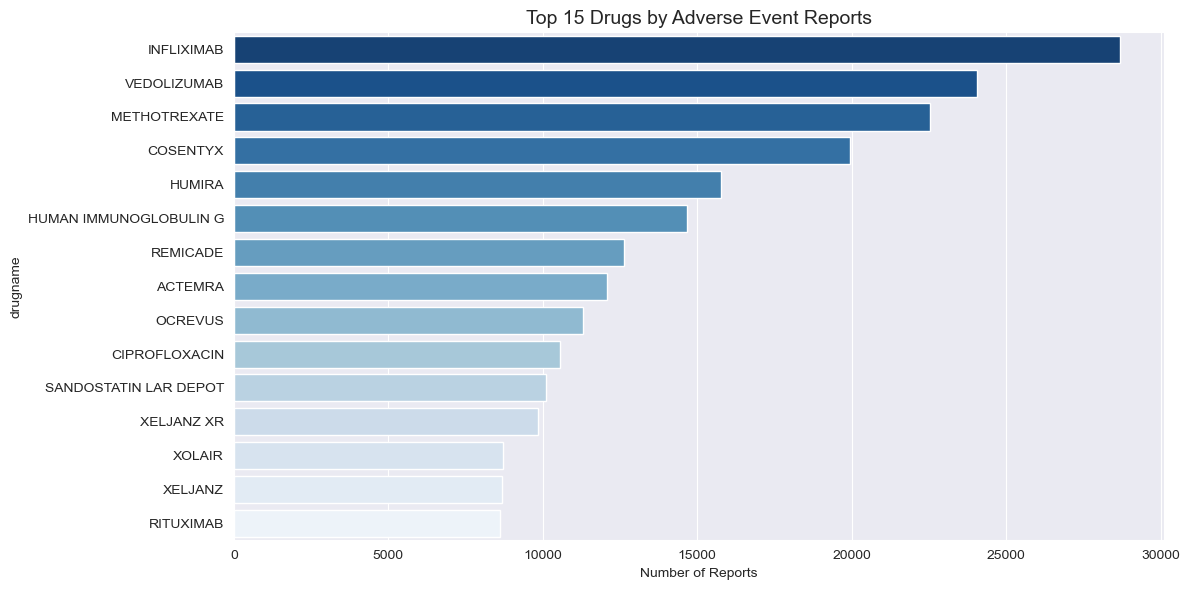

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\1820208372.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reactions.values, y=top_reactions.index, palette='Oranges_r')


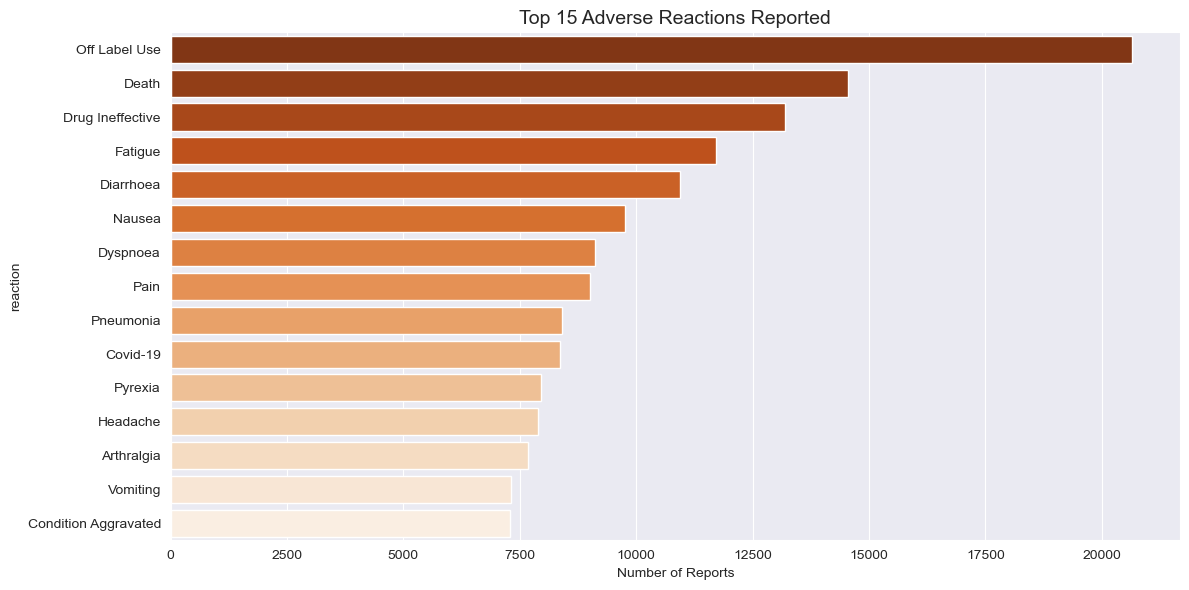

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\1820208372.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_fatal.index.astype(str), y=age_fatal.values, palette='YlOrRd')


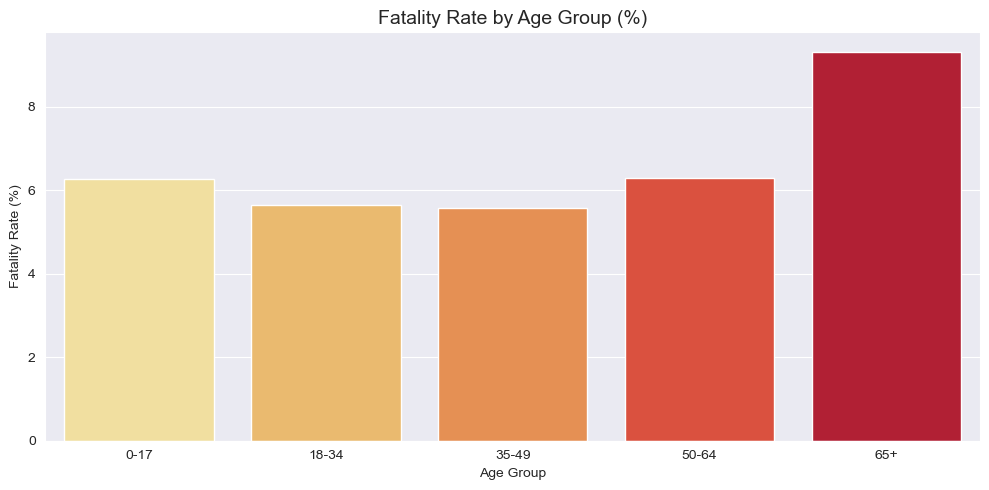

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\1820208372.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_fatal.index, y=sex_fatal.values, palette='Set2')


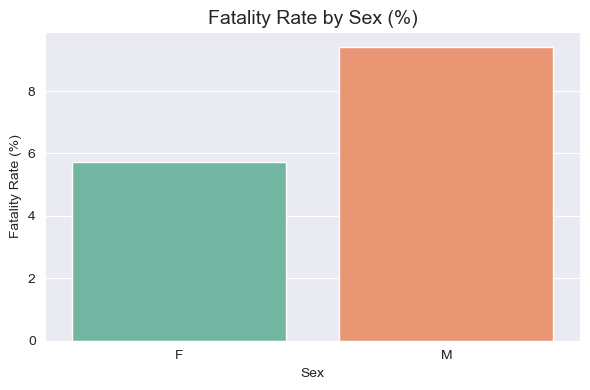

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\1820208372.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fatality_rate', y='drugname',


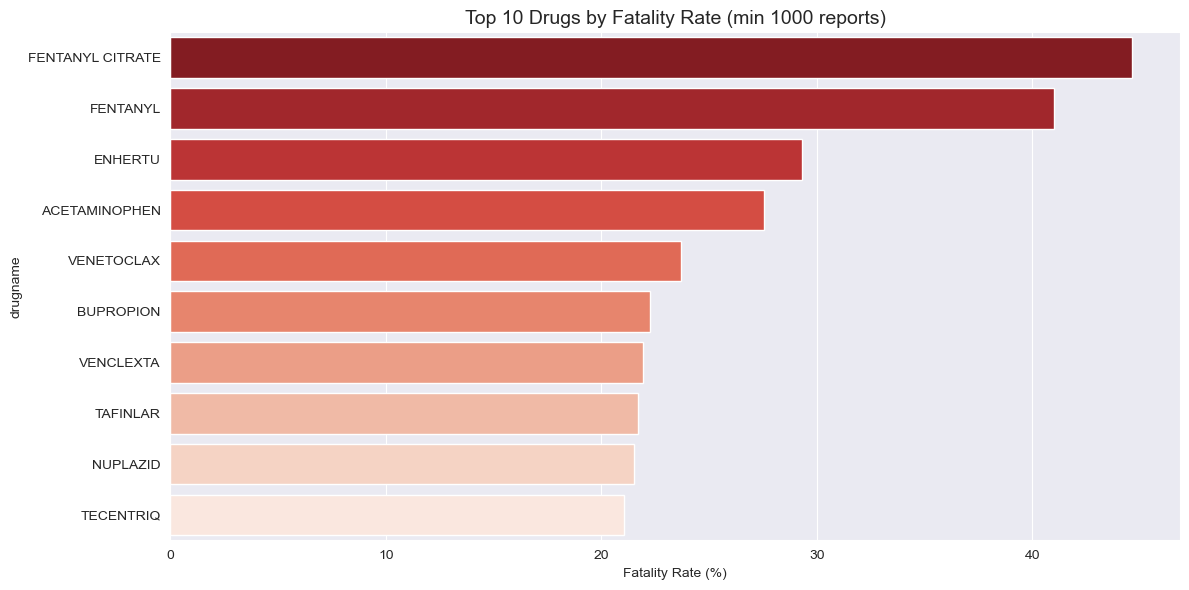

Overall Fatality Rate: 7.11%

Fatality Rate by Age Group:
age_group
0-17     6.28
18-34    5.64
35-49    5.57
50-64    6.29
65+      9.31
Name: is_fatal, dtype: float64

Fatality Rate by Sex:
sex
F    5.72
M    9.41
Name: is_fatal, dtype: float64

Top 10 Fatal Drugs:
              drugname  total_reports  fatality_rate
1319  FENTANYL CITRATE           1143          44.62
1318          FENTANYL           3607          41.00
1174           ENHERTU           1072          29.29
32       ACETAMINOPHEN           7748          27.54
3311        VENETOCLAX           4584          23.71
531          BUPROPION           1528          22.25
3310         VENCLEXTA           3552          21.93
3030          TAFINLAR           1474          21.71
2312          NUPLAZID           4090          21.52
3060         TECENTRIQ           1297          21.05


In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

# --- 1. Outcome Distribution ---
outcome_counts = merged['outcome_label'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=outcome_counts.values, y=outcome_counts.index, palette='Reds_r')
plt.title('Adverse Event Outcome Distribution', fontsize=14)
plt.xlabel('Number of Reports')
plt.tight_layout()
plt.show()

# --- 2. Top 15 Drugs by Report Count ---
top_drugs = merged['drugname'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_drugs.values, y=top_drugs.index, palette='Blues_r')
plt.title('Top 15 Drugs by Adverse Event Reports', fontsize=14)
plt.xlabel('Number of Reports')
plt.tight_layout()
plt.show()

# --- 3. Top 15 Reactions ---
top_reactions = merged['reaction'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_reactions.values, y=top_reactions.index, palette='Oranges_r')
plt.title('Top 15 Adverse Reactions Reported', fontsize=14)
plt.xlabel('Number of Reports')
plt.tight_layout()
plt.show()

# --- 4. Fatality Rate by Age Group ---
age_fatal = merged.groupby('age_group', observed=True)['is_fatal'].mean() * 100
plt.figure(figsize=(10, 5))
sns.barplot(x=age_fatal.index.astype(str), y=age_fatal.values, palette='YlOrRd')
plt.title('Fatality Rate by Age Group (%)', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Fatality Rate (%)')
plt.tight_layout()
plt.show()

# --- 5. Fatality Rate by Sex ---
sex_fatal = merged.groupby('sex')['is_fatal'].mean() * 100
plt.figure(figsize=(6, 4))
sns.barplot(x=sex_fatal.index, y=sex_fatal.values, palette='Set2')
plt.title('Fatality Rate by Sex (%)', fontsize=14)
plt.xlabel('Sex')
plt.ylabel('Fatality Rate (%)')
plt.tight_layout()
plt.show()

# --- 6. Top 10 Drugs by Fatality Rate (min 1000 reports) ---
drug_fatal = merged.groupby('drugname').agg(
    total_reports=('is_fatal', 'count'),
    fatal_cases=('is_fatal', 'sum')
).reset_index()
drug_fatal['fatality_rate'] = (drug_fatal['fatal_cases'] / 
                                drug_fatal['total_reports'] * 100).round(2)
drug_fatal_filtered = drug_fatal[drug_fatal['total_reports'] >= 1000]
top_fatal_drugs = drug_fatal_filtered.sort_values(
    'fatality_rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='fatality_rate', y='drugname', 
            data=top_fatal_drugs, palette='Reds_r')
plt.title('Top 10 Drugs by Fatality Rate (min 1000 reports)', fontsize=14)
plt.xlabel('Fatality Rate (%)')
plt.tight_layout()
plt.show()

# --- Print key numbers ---
print(f"Overall Fatality Rate: {merged['is_fatal'].mean()*100:.2f}%")
print(f"\nFatality Rate by Age Group:\n{age_fatal.round(2)}")
print(f"\nFatality Rate by Sex:\n{sex_fatal.round(2)}")
print(f"\nTop 10 Fatal Drugs:\n{top_fatal_drugs[['drugname','total_reports','fatality_rate']]}")

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\4137473829.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.values, y=outcome_counts.index, palette='Reds_r')


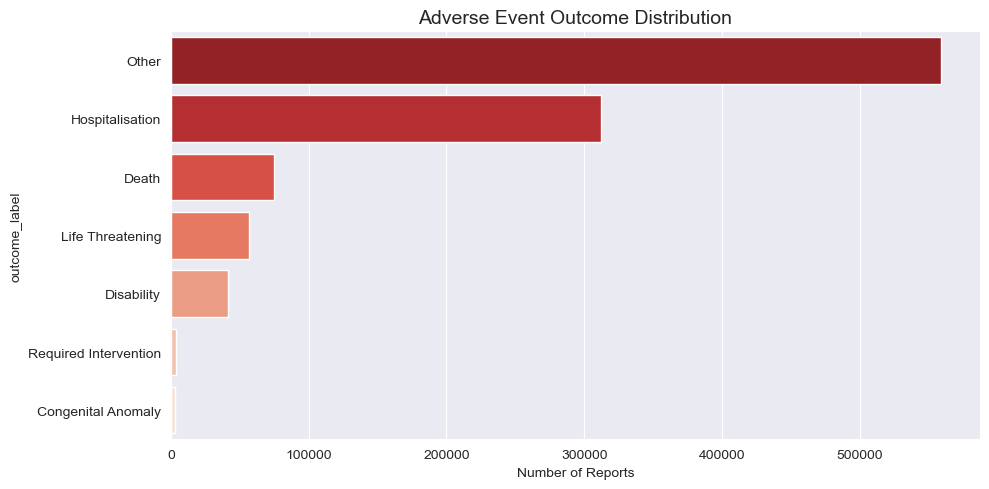

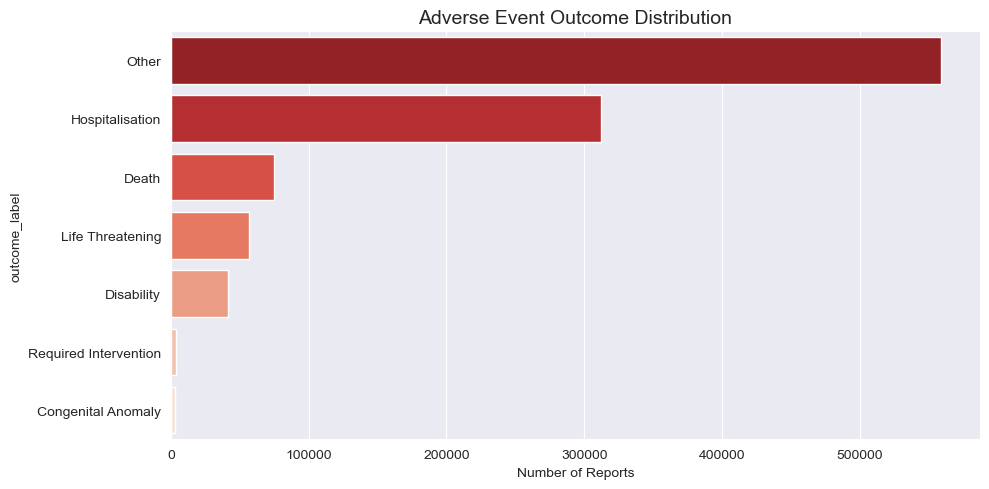

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\4137473829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_fatal.index.astype(str), y=age_fatal.values, palette='YlOrRd')


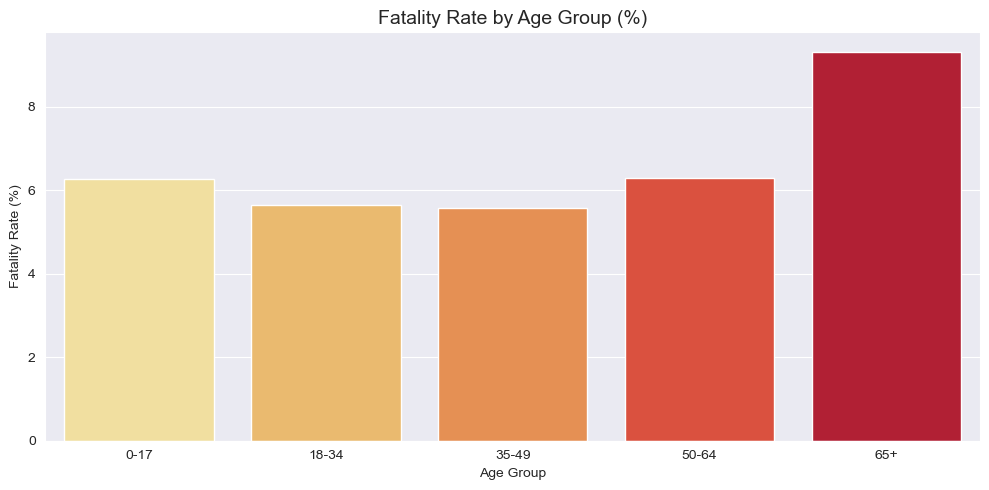

C:\Users\SHRUTI VAISHNAV\AppData\Local\Temp\ipykernel_8360\4137473829.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fatality_rate', y='drugname',


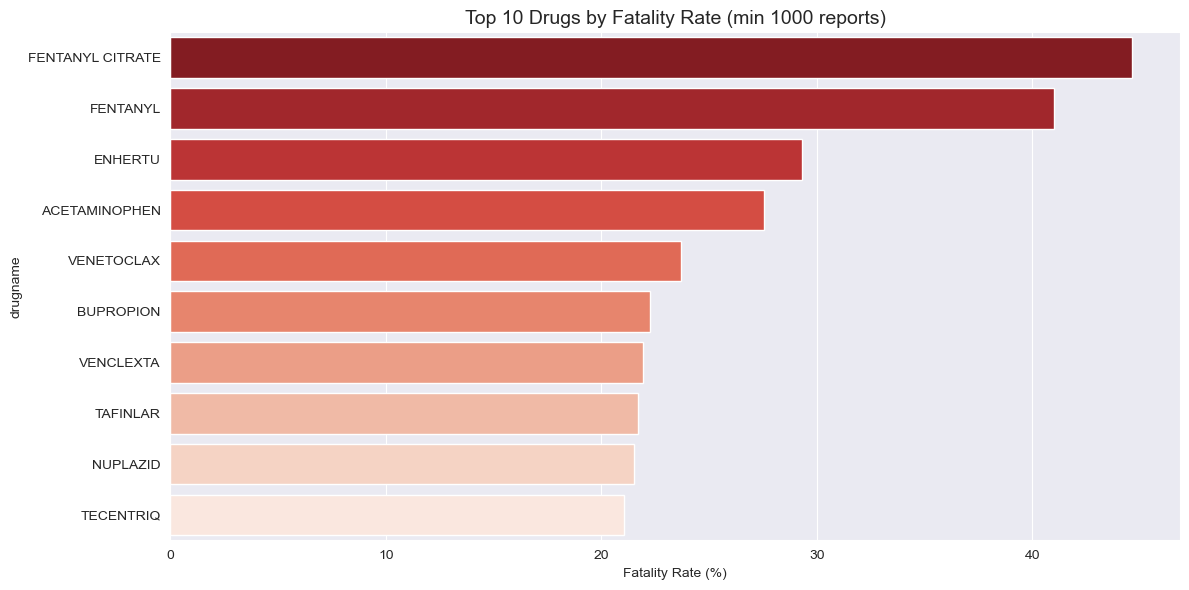

All plots saved.


In [26]:
# Save individual plots for GitHub and README

# Outcome distribution
outcome_counts = merged['outcome_label'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=outcome_counts.values, y=outcome_counts.index, palette='Reds_r')
plt.title('Adverse Event Outcome Distribution', fontsize=14)
plt.xlabel('Number of Reports')
plt.tight_layout()
plt.savefig(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\notebook\plot_outcome_distribution.png", dpi=150)
plt.show()

# Fatality by age group
plt.figure(figsize=(10, 5))
sns.barplot(x=age_fatal.index.astype(str), y=age_fatal.values, palette='YlOrRd')
plt.title('Fatality Rate by Age Group (%)', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Fatality Rate (%)')
plt.tight_layout()
plt.savefig(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\notebook\plot_fatality_age.png", dpi=150)
plt.show()

# Top fatal drugs
plt.figure(figsize=(12, 6))
sns.barplot(x='fatality_rate', y='drugname', 
            data=top_fatal_drugs, palette='Reds_r')
plt.title('Top 10 Drugs by Fatality Rate (min 1000 reports)', fontsize=14)
plt.xlabel('Fatality Rate (%)')
plt.tight_layout()
plt.savefig(r"C:\Users\SHRUTI VAISHNAV\OneDrive\Desktop\data science\fda-faers-adverse-event-analysis\notebook\plot_fatal_drugs.png", dpi=150)
plt.show()

print("All plots saved.")